# **Source-Photometry Lephare Identification Tool (SPLIT) for star-galaxy separation**

This is the notebook where we concatenate the whole functioning of SPLIT, an addons developped in parallel of LePHARE too . To run its whole pipeline, it takes in input the $\chi^2$ full library of LePhare (fullChi2). Hence there is two codes to run, divided in several steps each. If you don't have fullChi2, first you have to run LePHARE separately from SPLIT.
- **LePHARE**:
    - 1 - Build filter library.
    - 2 - Build sed library.
    - 3 - Build synthetic magnitude library.
    - 4 - Run photo-z

An example of command lines to use to run LePHARE from step 1 to 4 is avalaible in the StarGal folder of this repository in *stargal/LePHARE_for_SPLIT.txt*.


Then you can run SPLIT, in this notebook to control the steps and plot, or in script (*stargal/scripts/SPLIT.py*). In its core, it performs three main steps, which can be use independentely, depending on how efficient you want your stargal to be, and what do you have as inputs. It takes in input:
- **SPLIT**:
    - 1. $\chi^2_{best fit}$ comparison. Compare the best likelihood value from each library ($\chi^2_{star}$, $\chi^2_{gal}$) and compute the Bayesian Information Criterion (BIC): $\mathrm{BIC}_{m}=\chi^2_{m}+k_m\ln(n_{data}) \Rightarrow \mathrm{\Delta BIC}_{m,j}=\Delta\chi^2_{m,j}+(k_m-k_j)\ln(n_{data})$. Where $\Delta\chi^2_{m,j}=\chi^2_{m}-\chi^2_{j}$, $k_{m,j}$ is the number of free parameters in models {$m,j$} and $n_{data}$ is the number of observations for the source, i.e. $n_{bands}$ in our case. If $\Delta \mathrm{BIC} < 0$, model m is preferred, else it is model j. This is better than doing a direct $\chi^2_{m,j}$ comparison since the two models are non-nested in our case. Note that $\Delta \mathrm{BIC}$ is an approximation of $C_\mathrm{Bayes}$ for high $S/N$. It only requires $\chi^2_{best fit}$ of each models. 
    - 2. $\chi^2_{best fit}$ comparison. $C_\mathrm{Bayes} = 2\ln(B_{GS})$. It holds the same role as $\Delta \mathrm{BIC}$, but works at low $S/N$. It requires the full $\chi^2$ of LePHARE.
    - 3. Star-PDF. It does not classify if a source is either a star or a galaxy directly, but if it is a star or not. It requires the full $\chi^2$ of LePHARE, but from star SEDs only.

## **0. Initialization**

### 0.1 Packages

In [ ]:
### Libs ###
from imports import *

base_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(base_dir)

# Custom libraries
import scripts.statsplot as ssp
import scripts.utils as sutils
import scripts.split_src as SPLIT

%matplotlib inline

#--- Stats & Maths---

### 0.2 Entries

In [13]:
# The output of zphota is mandatory for BIC method
trilegal_BT_LSST_photoz = sutils.lephare_to_pandas(f"{base_dir}/catalogs/DC2/trilegal_dc2_errors_buzzard_BT_LSST_full.out")
dc2_BT_LSST_photoz = sutils.lephare_to_pandas(f"{base_dir}/catalogs/DC2/dp02_dc2_62_BT_LSST_full.out")
# trilegal_BT_LSST_photoz = dc2_BT_LSST_photoz[dc2_BT_LSST_photoz["ZSPEC"]==0]
# dc2_BT_LSST_photoz = dc2_BT_LSST_photoz[dc2_BT_LSST_photoz["ZSPEC"]>1][:6579]
photoz_cat = pd.concat((dc2_BT_LSST_photoz, trilegal_BT_LSST_photoz))

# --- DP1 ---
# dp1_cat = sutils.table_from_file(f'{base_dir}/catalogs/DP1/DP1_ECDFS_photometry.fits', output='pandas')
# dp1_lephare = sutils.lephare_to_pandas(f"{base_dir}/catalogs/DP1/DP1ecdfs_buzzard_BT_LSST_full.out")
# photoz_cat = sutils.join_tables(dp1_lephare, (dp1_cat[['refExtendedness', 'objectId']], 'IDENT', 'objectId'), how='left')
# photoz_cat= photoz_cat[['IDENT','CHI_BEST', 'CHI_STAR', 
#                             'MAG_OBS0', 'MAG_OBS1', 'MAG_OBS2', 'MAG_OBS3', 'MAG_OBS4', 'MAG_OBS5',
#                             'ERR_MAG_OBS0', 'ERR_MAG_OBS1', 'ERR_MAG_OBS2', 'ERR_MAG_OBS3', 'ERR_MAG_OBS4', 'ERR_MAG_OBS5', 
#                             'ZSPEC', 'refExtendedness']].copy()
# FullLib for Bayes method


In [14]:
# --- Keep what is useful ---

photoz_cat= photoz_cat[['IDENT','CHI_BEST', 'CHI_STAR', 
                            'MAG_OBS0', 'MAG_OBS1', 'MAG_OBS2', 'MAG_OBS3', 'MAG_OBS4', 'MAG_OBS5',
                            'ERR_MAG_OBS0', 'ERR_MAG_OBS1', 'ERR_MAG_OBS2', 'ERR_MAG_OBS3', 'ERR_MAG_OBS4', 'ERR_MAG_OBS5', 'ZSPEC']].copy()

# ZSPEC=0 -> star
photoz_cat["IS_STAR"] = (photoz_cat["ZSPEC"] == 0).astype(int)
# photoz_cat["IS_STAR"] = (photoz_cat["refExtendedness"] == 0).astype(int)
photoz_cat[photoz_cat["IS_STAR"]==1][:3]

,IDENT,CHI_BEST,CHI_STAR,MAG_OBS0,MAG_OBS1,MAG_OBS2,MAG_OBS3,MAG_OBS4,MAG_OBS5,ERR_MAG_OBS0,ERR_MAG_OBS1,ERR_MAG_OBS2,ERR_MAG_OBS3,ERR_MAG_OBS4,ERR_MAG_OBS5,ZSPEC,IS_STAR
0,1651413688361421449,2.52301,5.54265,26.112,26.669,25.962,25.452,25.985,24.877,0.445,0.249,0.155,0.191,0.823,0.523,0.0,1
1,1651413688361451863,5.76531,19.80850,28.114,25.847,25.458,24.611,24.224,24.009,2.443,0.108,0.091,0.082,0.145,0.210,0.0,1
193,1651413688361451488,537.11800,72.19620,22.446,21.390,21.021,20.882,20.846,20.826,0.012,0.002,0.001,0.002,0.005,0.010,0.0,1


In [15]:
#--- Algorithms to use ---
use_BIC = True
use_bayes = False
use_starpdf = False
probability_threshold = 0.95 # [0,1] If specified, whenever the probability threshold has been crossed, 
                             # stop the algorithm for the current source at the current probability result.
                             # to choose after computing ROC/RP curves 

#--- Parameters ---
kG = 3 # dof of model A. Unknow, Z, alpha (normalisation)
kS = 3 # dof of model B. Teff, logg, FeH, alpha (normalisation)
nbands = 6   # ugrizy

#--- Preferences ---
ignore_aberrant_Z = True # sometimes best-likelihood can't be compute during photo-z
                         # yet it returns Z = -99


## **1. $\chi^2_{best fit}$ Comparison**

## **2. Bayes Factor**

## **3. Star-PDF**

## **4. Main**

In [17]:
if ignore_aberrant_Z == True:
    photoz_cat = photoz_cat[photoz_cat['CHI_BEST']<1e9]

P_STAR_BIC = []

#--- BIC ---
if use_BIC == True:
    for source in photoz_cat.itertuples():
        chiG = source.CHI_BEST
        chiS = source.CHI_STAR
        BIC_G = SPLIT.BIC(chiG, kG, nbands)
        BIC_S = SPLIT.BIC(chiS, kS, nbands)
        pBIC_Gx, pBIC_Sx = SPLIT.model_prob_from_chi(BIC_G, BIC_S)#, prior_A=0.9,prior_B=0.1)
        P_STAR_BIC.append(pBIC_Sx)

photoz_cat["P_STAR_BIC"] = P_STAR_BIC

photoz_cat_badPstar = photoz_cat[
        photoz_cat["P_STAR_BIC"]<probability_threshold # continue for the sources with not satisfying PSTAR
        ]

# #--- PDF Star ---
# split = SPLIT(pdf_dict)
# probs = split.classify_sample(photoz_cat_badPstar, priors=None, use_weights=True)
# final = pd.concat([photoz_cat_badPstar, probs], axis=1)



/home/hallouin/Documents/t_hall/lephare/stargal/scripts/split_src.py:32: RuntimeWarning: invalid value encountered in scalar divide
  return wA / norm, wB / norm


## **5. Stats**

In [18]:
n_s = len(photoz_cat[(photoz_cat["P_STAR_BIC"]>0.98) & (photoz_cat["IS_STAR"]==1)])
n_g = len(photoz_cat[(photoz_cat["P_STAR_BIC"]>0.98) & (photoz_cat["IS_STAR"]==0)])
n_s/(n_s+n_g)

0.9006864605424713

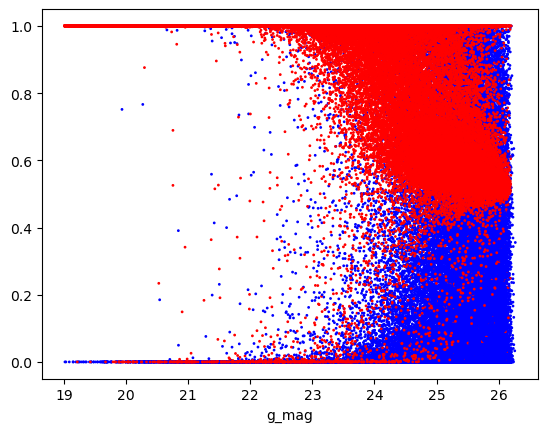

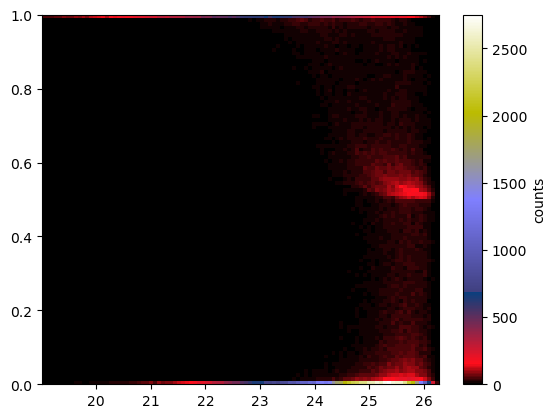

In [19]:
df_plot = photoz_cat[(photoz_cat["MAG_OBS1"]>19) & (photoz_cat["MAG_OBS1"]<27) & (photoz_cat["ERR_MAG_OBS1"]<0.1)].dropna() # & (photoz_cat["IS_STAR"]==1)
# df_plot = df_plot[(df_plot["P_STAR_BIC"]<0.4) | (df_plot["P_STAR_BIC"]>0.65)]
plt.figure()
plt.scatter(df_plot["MAG_OBS1"], df_plot["P_STAR_BIC"], c=df_plot["IS_STAR"], s=1, cmap="bwr")
# plt.xlim(0,0.1)
plt.xlabel('g_mag')
plt.show()

plt.figure()
plt.hist2d(df_plot["MAG_OBS1"], df_plot["P_STAR_BIC"], bins=(100,100), cmap='gist_stern')
plt.colorbar(label="counts")
plt.show()

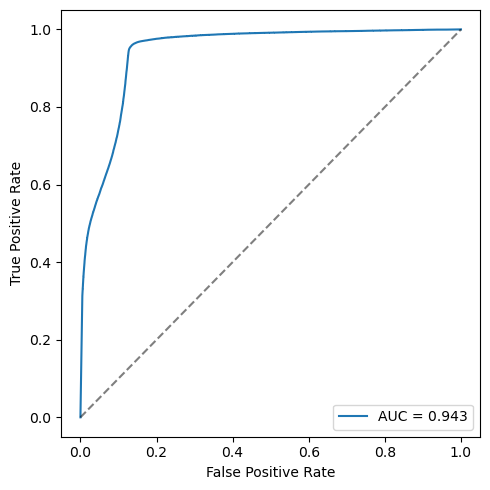

In [120]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve

fpr, tpr, thresholds = roc_curve(df_plot["IS_STAR"], df_plot["P_STAR_BIC"], pos_label=1)


roc_auc = auc(fpr, tpr)
plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], "k--", alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()


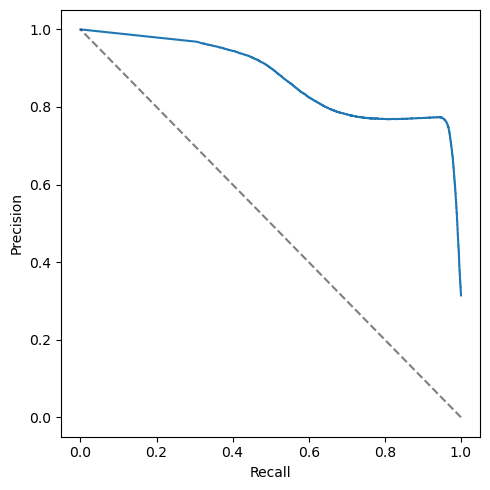

In [121]:
from sklearn.metrics import precision_recall_curve

y_true = df_plot["IS_STAR"].values
y_score = df_plot["P_STAR_BIC"].values

precision, recall, thresholds = precision_recall_curve(y_true, y_score)

plt.figure(figsize=(5,5))
plt.plot(recall, precision)
plt.plot([1,0], [0,1], "k--", alpha=0.5)
plt.xlabel("Recall")
plt.ylabel("Precision")
# plt.legend()
plt.tight_layout()
plt.show()

In [25]:
# target_precision = 0.9
# valid = precision[:-1] >= target_precision


target_purity = 0.9
valid = precision[:-1] >= target_purity

if not np.any(valid):
    print("No threshold reaches 95% purity")
else:
    idx = np.where(valid)[0]
idx

if not np.any(valid):
    raise RuntimeError("No threshold reaches 95% precision")

# among valid thresholds, choose the one with MAX recall
best_idx = np.argmax(recall[:-1][valid])
threshold_idx = np.where(valid)[0][best_idx]
pstar_threshold = thresholds[threshold_idx]
pstar_threshold

np.float64(0.9210242119820476)